# 06b — LSTM Walk-Forward (Weekly, retrain every 20 steps)

Variant of `06_lstm.ipynb` that **fine-tunes the trained model every 20 test steps**
instead of training once and predicting the full test set in one pass. Same data,
same `MARKET_FEATURES` / `TECH_COLS`, same variant ladder.

**Why this version exists.** With ~330 training sequences, retraining every 4 steps
was tested and severely degraded performance — each fine-tune ran 30 epochs on ~4
new observations, so the gradient updates were mostly noise and the network drifted
away from its tuned configuration (catastrophic forgetting). At 20 steps the fine-tune
sees ~5 months of new data, the number of retrain events drops from ~38 to ~8, and
the model can track slow regime changes without losing the patterns it learned from
the full training set.

**Procedure**:
1. Train each variant once on train+val with early stopping (same as `06_lstm.ipynb`).
2. Walk forward through the test set predicting one step at a time.
3. Every `RETRAIN_EVERY = 20` steps, fine-tune the model for `FT_EPOCHS = 10` at
   `LR × 0.3` using **all data up to that point** (train + val + seen test). The
   `StandardScaler` is fixed on train+val to avoid any look-ahead in feature scaling.
4. Resume one-step-ahead prediction with the fine-tuned weights.

**Outputs**:
- `metrics_lstm_weekly_walkforward.csv` (sits next to `metrics_lstm_weekly.csv`)
- `period_lstm_weekly_walkforward.csv`
- Checkpoint files use a `_wf` suffix so the single-train checkpoints aren't overwritten.

`EXOG` = weekly silver return + 6 cross-asset returns (gold, USD, copper, S&P500, VIX, oil).

| Variant | Features |
|---|---|
| LSTM-Y | Silver return only |
| LSTM-TECH | Silver + macd\_line, macd\_hist, bb\_bandwidth, silver\_vol\_5w (no cross-assets) |
| LSTM-EXOG | Silver + 6 cross-asset returns |
| LSTM-EXOG-TECH | EXOG + tech indicators |
| LSTM-EXOG-REDDIT | EXOG + Reddit sentiment |
| LSTM-EXOG-NEWS | EXOG + news sentiment |
| LSTM-EXOG-SENTIMENT | EXOG + Reddit + news sentiment |
| LSTM-EXOG-TECH-SENTIMENT | EXOG + tech + Reddit + news sentiment |

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import warnings, os, sys
warnings.filterwarnings('ignore')

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 120

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)

Device: mps


## 1. Hyperparameters

In [23]:
SEQ_LEN  = 20    # lookback: 20 weeks (~5 months)
HORIZON  = 1     # 1 week ahead
HIDDEN   = 32
N_LAYERS = 1
DROPOUT  = 0.2
EPOCHS   = 150
LR       = 1e-3
PATIENCE = 15
BATCH    = 16    # smaller batch — fewer sequences

# Walk-forward retraining
RETRAIN_EVERY = 20      # fine-tune every N test steps
FT_EPOCHS     = 2       # very low — Stage 1 already found the optimum, just nudge weights
FT_LR_FACTOR  = 0.3     # fine-tune LR = LR * factor

TARGET = 'silver_return'

## 2. Load & aggregate to weekly

In [24]:
train_d = pd.read_csv('../../data/processed/train.csv', index_col=0, parse_dates=True)
val_d   = pd.read_csv('../../data/processed/val.csv',   index_col=0, parse_dates=True)
test_d  = pd.read_csv('../../data/processed/test.csv',  index_col=0, parse_dates=True)

EXOG = ['gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return']
FEAT_COLS = [TARGET] + [c for c in EXOG if c in train_d.columns]

# Aggregate: returns sum (additive), sentiment mean
def to_weekly(df):
    return df[FEAT_COLS].resample('W-FRI').sum().dropna()

train = to_weekly(train_d)
val   = to_weekly(val_d)
test  = to_weekly(test_d)

# Merge weekly sentiment if available
sent_path = '../../data/processed/daily_sentiment.csv'
if os.path.exists(sent_path):
    sent = pd.read_csv(sent_path, index_col=0, parse_dates=True)
    sent_w = sent[['reddit_sentiment','news_sentiment']].resample('W-FRI').mean()
    for df in [train, val, test]:
        for col in ['reddit_sentiment','news_sentiment']:
            df[col] = sent_w[col].reindex(df.index).ffill().fillna(0)
    print('Sentiment merged.')
else:
    for df in [train, val, test]:
        df['reddit_sentiment'] = 0.0
        df['news_sentiment']   = 0.0

print(f'Train weeks: {len(train)}  Val weeks: {len(val)}  Test weeks: {len(test)}')
print(f'Features: {train.columns.tolist()}')

Sentiment merged.
Train weeks: 365  Val weeks: 52  Test weeks: 175
Features: ['silver_return', 'gold_return', 'usd_return', 'copper_return', 'sp500_return', 'vix_return', 'oil_return', 'reddit_sentiment', 'news_sentiment']


In [25]:
# Compute the 4 weekly technical indicators (same as RF/XGBoost notebooks).
# Lagged by 1 week before joining — no lookahead.
prices   = pd.read_csv('../../data/raw/daily_prices.csv', index_col=0, parse_dates=True)
silver_w = prices['silver'].resample('W-FRI').last().dropna()

ema_fast    = silver_w.ewm(span=12, adjust=False).mean()
ema_slow    = silver_w.ewm(span=26, adjust=False).mean()
macd_line   = ema_fast - ema_slow
macd_signal = macd_line.ewm(span=9, adjust=False).mean()

ind_w = pd.DataFrame({
    'macd_line':     macd_line,
    'macd_hist':     macd_line - macd_signal,
    'bb_bandwidth':  4 * silver_w.rolling(20).std() / silver_w.rolling(20).mean(),
    'silver_vol_5w': np.log(silver_w / silver_w.shift(1)).rolling(5).std(),
}, index=silver_w.index).shift(1)

TECH_COLS = ['macd_line', 'macd_hist', 'bb_bandwidth', 'silver_vol_5w']
for df in [train, val, test]:
    for col in TECH_COLS:
        df[col] = ind_w[col].reindex(df.index).fillna(0)

print(f'Technical indicators joined: {TECH_COLS}')

Technical indicators joined: ['macd_line', 'macd_hist', 'bb_bandwidth', 'silver_vol_5w']


## 3. Architecture & helpers

In [26]:
class LSTMForecaster(nn.Module):
    def __init__(self, input_size, hidden_size=32, num_layers=1, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                            batch_first=True, dropout=dropout)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])


def make_sequences(data, seq_len, target_col, horizon=1):
    X, y = [], []
    for i in range(seq_len, len(data) - horizon + 1):
        X.append(data[i - seq_len:i])
        y.append(np.sum(data[i:i + horizon, target_col]))
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)


def run_variant(name, feature_cols):
    print(f'\n{"=" * 50}\nVariant: {name}\n{"=" * 50}')
    cols       = [c for c in feature_cols if c in train.columns]
    target_idx = cols.index(TARGET)

    # Scaler fit on train only — no look-ahead in feature scaling.
    scaler = StandardScaler().fit(train[cols].fillna(0))
    tr_s   = scaler.transform(train[cols].fillna(0))
    va_s   = scaler.transform(val[cols].fillna(0))
    te_s   = scaler.transform(test[cols].fillna(0))

    X_tr, y_tr = make_sequences(tr_s, SEQ_LEN, target_idx, HORIZON)
    X_va, y_va = make_sequences(va_s, SEQ_LEN, target_idx, HORIZON)
    X_te, y_te = make_sequences(te_s, SEQ_LEN, target_idx, HORIZON)
    dates      = test.index[SEQ_LEN:len(test) - HORIZON + 1]

    print(f'  Train seqs: {len(X_tr)}  Val seqs: {len(X_va)}  Test seqs: {len(X_te)}')

    def to_loader(X, y, shuffle=True):
        ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
        return DataLoader(ds, batch_size=BATCH, shuffle=shuffle)

    train_loader = to_loader(X_tr, y_tr)
    val_loader   = to_loader(X_va, y_va, shuffle=False)

    safe_name = name.lower().replace("+","_").replace(" ","_")
    ckpt = f'../../data/processed/lstm_{safe_name}_weekly_wf_best.pt'

    model = LSTMForecaster(len(cols), HIDDEN, N_LAYERS, DROPOUT).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    crit  = nn.MSELoss()
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=3, factor=0.5)

    # ── Stage 1: initial training with early stopping on val loss ────────────
    best_val, pat_cnt = np.inf, 0
    for epoch in range(1, EPOCHS + 1):
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            opt.zero_grad()
            loss = crit(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
        model.eval()
        with torch.no_grad():
            vl = np.mean([crit(model(xb.to(DEVICE)), yb.to(DEVICE)).item()
                          for xb, yb in val_loader])
        sched.step(vl)
        if epoch % 25 == 0:
            print(f'  Epoch {epoch:3d}  val={vl:.6f}')
        if vl < best_val:
            best_val, pat_cnt = vl, 0
            torch.save(model.state_dict(), ckpt)
        else:
            pat_cnt += 1
            if pat_cnt >= PATIENCE:
                print(f'  Early stopping at epoch {epoch}')
                break

    model.load_state_dict(torch.load(ckpt))

    # ── Stage 2: walk forward through test set, fine-tuning every RETRAIN_EVERY ──
    # Build the cumulative pool of training sequences (train + val) and grow it
    # as we walk through the test set.
    pool_X = np.concatenate([X_tr, X_va])
    pool_y = np.concatenate([y_tr, y_va])

    preds_s, acts_s = [], []
    n_retrain       = 0

    for i in range(len(X_te)):
        # Predict step i
        model.eval()
        with torch.no_grad():
            xb = torch.tensor(X_te[i:i+1]).to(DEVICE)
            preds_s.append(model(xb).cpu().numpy().flatten()[0])
        acts_s.append(float(y_te[i]))

        # Grow training pool with the just-realised observation
        pool_X = np.concatenate([pool_X, X_te[i:i+1]])
        pool_y = np.concatenate([pool_y, y_te[i:i+1]])

        # Fine-tune every RETRAIN_EVERY steps (skip the final step)
        if (i + 1) % RETRAIN_EVERY == 0 and (i + 1) < len(X_te):
            n_retrain += 1
            ft_opt    = torch.optim.Adam(model.parameters(), lr=LR * FT_LR_FACTOR)
            ft_loader = to_loader(pool_X, pool_y, shuffle=True)
            model.train()
            for _ in range(FT_EPOCHS):
                for xb, yb in ft_loader:
                    xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                    ft_opt.zero_grad()
                    loss = crit(model(xb), yb)
                    loss.backward()
                    nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                    ft_opt.step()

    print(f'  Fine-tune events: {n_retrain} (every {RETRAIN_EVERY} steps)')

    mu, sigma  = scaler.mean_[target_idx], scaler.scale_[target_idx]
    preds      = np.array(preds_s) * sigma + HORIZON * mu
    actuals    = np.array(acts_s)  * sigma + HORIZON * mu

    rmse = np.sqrt(mean_squared_error(actuals, preds))
    mae  = mean_absolute_error(actuals, preds)
    da   = np.mean(np.sign(actuals) == np.sign(preds))
    wda  = np.sum(np.abs(actuals) * (np.sign(actuals) == np.sign(preds))) / np.sum(np.abs(actuals))
    print(f'  RMSE={rmse:.6f}  MAE={mae:.6f}  DA={da:.3f}  WDA={wda:.3f}')
    print(f'  Test sequences: {len(preds)} weekly predictions')

    return {'model': name, 'rmse': rmse, 'mae': mae, 'dir_acc': da, 'wda': wda}, preds, actuals, dates

## 4. Train variants

In [27]:
MARKET_FEATURES = [TARGET] + [c for c in EXOG if c in train.columns]

variants = {
    'LSTM-Y':                   [TARGET],
    'LSTM-TECH':                [TARGET] + TECH_COLS,
    'LSTM-EXOG':                MARKET_FEATURES,
    'LSTM-EXOG-TECH':           MARKET_FEATURES + TECH_COLS,
    'LSTM-EXOG-REDDIT':         MARKET_FEATURES + ['reddit_sentiment'],
    'LSTM-EXOG-NEWS':           MARKET_FEATURES + ['news_sentiment'],
    'LSTM-EXOG-SENTIMENT':      MARKET_FEATURES + ['reddit_sentiment', 'news_sentiment'],
    'LSTM-EXOG-TECH-SENTIMENT': MARKET_FEATURES + TECH_COLS + ['reddit_sentiment', 'news_sentiment'],
}

results     = {}
all_preds   = {}
actuals_arr = None
dates_arr   = None

for name, cols in variants.items():
    m, preds, acts, dates = run_variant(name, cols)
    results[name]   = m
    all_preds[name] = preds
    actuals_arr     = acts
    dates_arr       = dates


Variant: LSTM-Y
  Train seqs: 345  Val seqs: 32  Test seqs: 155
  Early stopping at epoch 18
  Fine-tune events: 7 (every 20 steps)
  RMSE=0.053583  MAE=0.038328  DA=0.542  WDA=0.498
  Test sequences: 155 weekly predictions

Variant: LSTM-TECH
  Train seqs: 345  Val seqs: 32  Test seqs: 155
  Early stopping at epoch 18
  Fine-tune events: 7 (every 20 steps)
  RMSE=0.054335  MAE=0.039135  DA=0.452  WDA=0.446
  Test sequences: 155 weekly predictions

Variant: LSTM-EXOG
  Train seqs: 345  Val seqs: 32  Test seqs: 155
  Early stopping at epoch 18
  Fine-tune events: 7 (every 20 steps)
  RMSE=0.053438  MAE=0.038272  DA=0.490  WDA=0.471
  Test sequences: 155 weekly predictions

Variant: LSTM-EXOG-TECH
  Train seqs: 345  Val seqs: 32  Test seqs: 155
  Early stopping at epoch 16
  Fine-tune events: 7 (every 20 steps)
  RMSE=0.054327  MAE=0.038912  DA=0.465  WDA=0.392
  Test sequences: 155 weekly predictions

Variant: LSTM-EXOG-REDDIT
  Train seqs: 345  Val seqs: 32  Test seqs: 155
  Early sto

## 5. Results

In [28]:
metrics_df = pd.DataFrame(list(results.values()))
metrics_df.to_csv('../../data/processed/metrics_lstm_weekly_walkforward.csv', index=False)

print(f'{"Model":<30}  {"RMSE":>10}  {"MAE":>10}  {"DA":>6}  {"WDA":>6}')
print('-' * 68)
for _, row in metrics_df.iterrows():
    print(f'{row["model"]:<30}  {row["rmse"]:>10.6f}  {row["mae"]:>10.6f}'
          f'  {row["dir_acc"]:>6.3f}  {row["wda"]:>6.3f}')

Model                                 RMSE         MAE      DA     WDA
--------------------------------------------------------------------
LSTM-Y                            0.053583    0.038328   0.542   0.498
LSTM-TECH                         0.054335    0.039135   0.452   0.446
LSTM-EXOG                         0.053438    0.038272   0.490   0.471
LSTM-EXOG-TECH                    0.054327    0.038912   0.465   0.392
LSTM-EXOG-REDDIT                  0.053645    0.038388   0.490   0.487
LSTM-EXOG-NEWS                    0.053502    0.038304   0.548   0.575
LSTM-EXOG-SENTIMENT               0.053662    0.038394   0.523   0.513
LSTM-EXOG-TECH-SENTIMENT          0.054339    0.038945   0.465   0.456


## 6. Period breakdown

In [29]:
sys.path.insert(0, os.path.abspath('../../src'))
from eval_utils import period_metrics, diebold_mariano, PERIODS

best_name = max(results, key=lambda k: results[k]['wda'])
best_pred = all_preds[best_name]
print('Best variant by WDA:', best_name)

res = period_metrics(actuals_arr, best_pred, dates_arr, PERIODS)
display(res[['n', 'DA', 'WDA']].style
        .format({'n': '{:.0f}', 'DA': '{:.3f}', 'WDA': '{:.3f}'})
        .background_gradient(cmap='RdYlGn', subset=['DA', 'WDA'], vmin=0.35, vmax=0.65))
res[['n', 'DA', 'WDA']].to_csv('../../data/processed/period_lstm_weekly_walkforward.csv')

Best variant by WDA: LSTM-EXOG-NEWS


,n,DA,WDA
Period,,,
2023 (choppy),32,0.656,0.697
2024 (bull start),52,0.500,0.556
2025 (bull run),52,0.538,0.544
2026 (YTD),19,0.526,0.542
── Full test ──,155,0.548,0.575


## 7. Diebold-Mariano tests

Tests whether each variant produces statistically significant forecast improvements
over the LSTM-EXOG baseline (market features only).
H0: equal predictive accuracy (squared error loss). p < 0.05 = significant improvement.

In [30]:
print("Diebold-Mariano tests — each variant vs LSTM-EXOG baseline")
print("H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant")
print("-" * 90)

baseline_key  = 'LSTM-EXOG'
baseline_pred = all_preds[baseline_key]
for name, pred in all_preds.items():
    if name == baseline_key:
        continue
    diebold_mariano(actuals_arr, baseline_pred, pred, baseline_key, name)

Diebold-Mariano tests — each variant vs LSTM-EXOG baseline
H0: equal predictive accuracy  |  * p<0.05  ** p<0.01  *** p<0.001  ns=not significant
------------------------------------------------------------------------------------------
LSTM-EXOG                                vs LSTM-Y                                    DM=-1.008  p=0.313  (ns)
LSTM-EXOG                                vs LSTM-TECH                                 DM=-2.849  p=0.004  **
  -> LSTM-EXOG is significantly more accurate
LSTM-EXOG                                vs LSTM-EXOG-TECH                            DM=-2.117  p=0.034  *
  -> LSTM-EXOG is significantly more accurate
LSTM-EXOG                                vs LSTM-EXOG-REDDIT                          DM=-0.907  p=0.364  (ns)
LSTM-EXOG                                vs LSTM-EXOG-NEWS                            DM=-0.393  p=0.694  (ns)
LSTM-EXOG                                vs LSTM-EXOG-SENTIMENT                       DM=-0.914  p=0.361  (ns)
LSTM-EXOG 

## 8. 2026 zoom — actual vs best variant

Focuses on the most recent out-of-sample weeks where silver has been most active.
Uses the best-performing LSTM variant by WDA (same `best_name` / `best_pred`
as the sub-period breakdown).

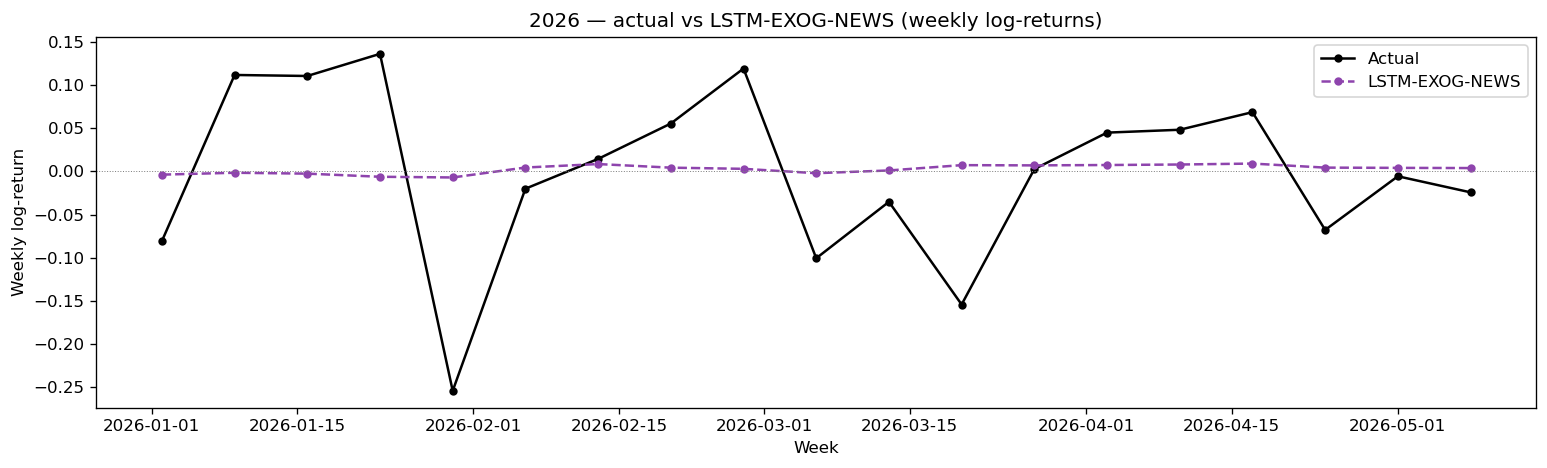

In [31]:
df26 = pd.DataFrame({"actual": actuals_arr, "pred": best_pred},
                    index=pd.DatetimeIndex(dates_arr))
df26 = df26.loc["2026":]

if df26.empty:
    print("No 2026 data in test set yet.")
else:
    fig, ax = plt.subplots(figsize=(13, 4))
    ax.plot(df26.index, df26["actual"], color="black",  lw=1.5, marker="o", ms=4, label="Actual")
    ax.plot(df26.index, df26["pred"],   color="#8e44ad", lw=1.5, marker="o", ms=4,
            ls="--", label=f"{best_name}")
    ax.axhline(0, color="grey", lw=0.6, ls=":")
    ax.set_title(f"2026 — actual vs {best_name} (weekly log-returns)", fontsize=12)
    ax.set_ylabel("Weekly log-return")
    ax.set_xlabel("Week")
    ax.legend()
    plt.tight_layout()
    plt.show()